
## Ejercicio 2


In [1]:
# Importación de librerías para manipulación de datos
import pandas as pd
import numpy as np

# Importación de librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de herramientas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv('/content/drive/MyDrive/penguins.csv')

display(df.head())
print("\n--- Información del Dataset ---")
df.info()

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007



--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [28]:
def imputar_valores_nulos(dataframe):
    """
    Función reutilizable para imputar valores nulos en un DataFrame.
    - Numéricos: Se rellenan con la mediana (más robusta ante valores atípicos).
    - Categóricos: Se rellenan con la moda (el valor más frecuente).
    """
    df_clean = dataframe.copy()

    for columna in df_clean.columns:
        if df_clean[columna].isnull().sum() > 0:
            if df_clean[columna].dtype in ['float64', 'int64']:
                # Imputación para numéricos
                mediana = df_clean[columna].median()
                df_clean[columna] = df_clean[columna].fillna(mediana)
            else:
                # Imputación para categóricos (texto)
                moda = df_clean[columna].mode()[0]
                df_clean[columna] = df_clean[columna].fillna(moda)

    return df_clean

df_clean = imputar_valores_nulos(df)
print("Valores nulos después de la imputación:\n", df_clean.isnull().sum())

# --- Validar la retención de datos tras la limpieza ---
registros_iniciales = len(df)
registros_actuales = len(df_clean)
datos_perdidos = registros_iniciales - registros_actuales

print("\n--- Resumen de Retención de Datos ---")
print(f"Total de registros originales: {registros_iniciales}")
print(f"Registros eliminados por nulos: {datos_perdidos} (Se usó imputación matemática)")
print(f"Total de datos para análisis (EDA): {registros_actuales} (Retención del 100%)")

Valores nulos después de la imputación:
 Unnamed: 0           0
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

--- Resumen de Retención de Datos ---
Total de registros originales: 344
Registros eliminados por nulos: 0 (Se usó imputación matemática)
Total de datos para análisis (EDA): 344 (Retención del 100%)


In [5]:
# Eliminar columnas que no aportan información predictiva biológica
columnas_a_eliminar = ['Unnamed: 0', 'year']
df_clean = df_clean.drop(columns=[col for col in columnas_a_eliminar if col in df_clean.columns])

print("Columnas actuales en el dataset:")
print(df_clean.columns.tolist())

Columnas actuales en el dataset:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


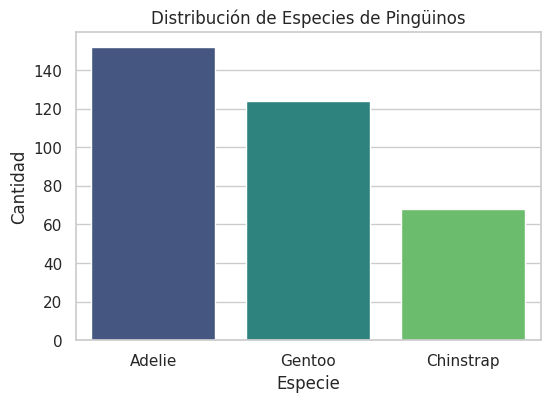

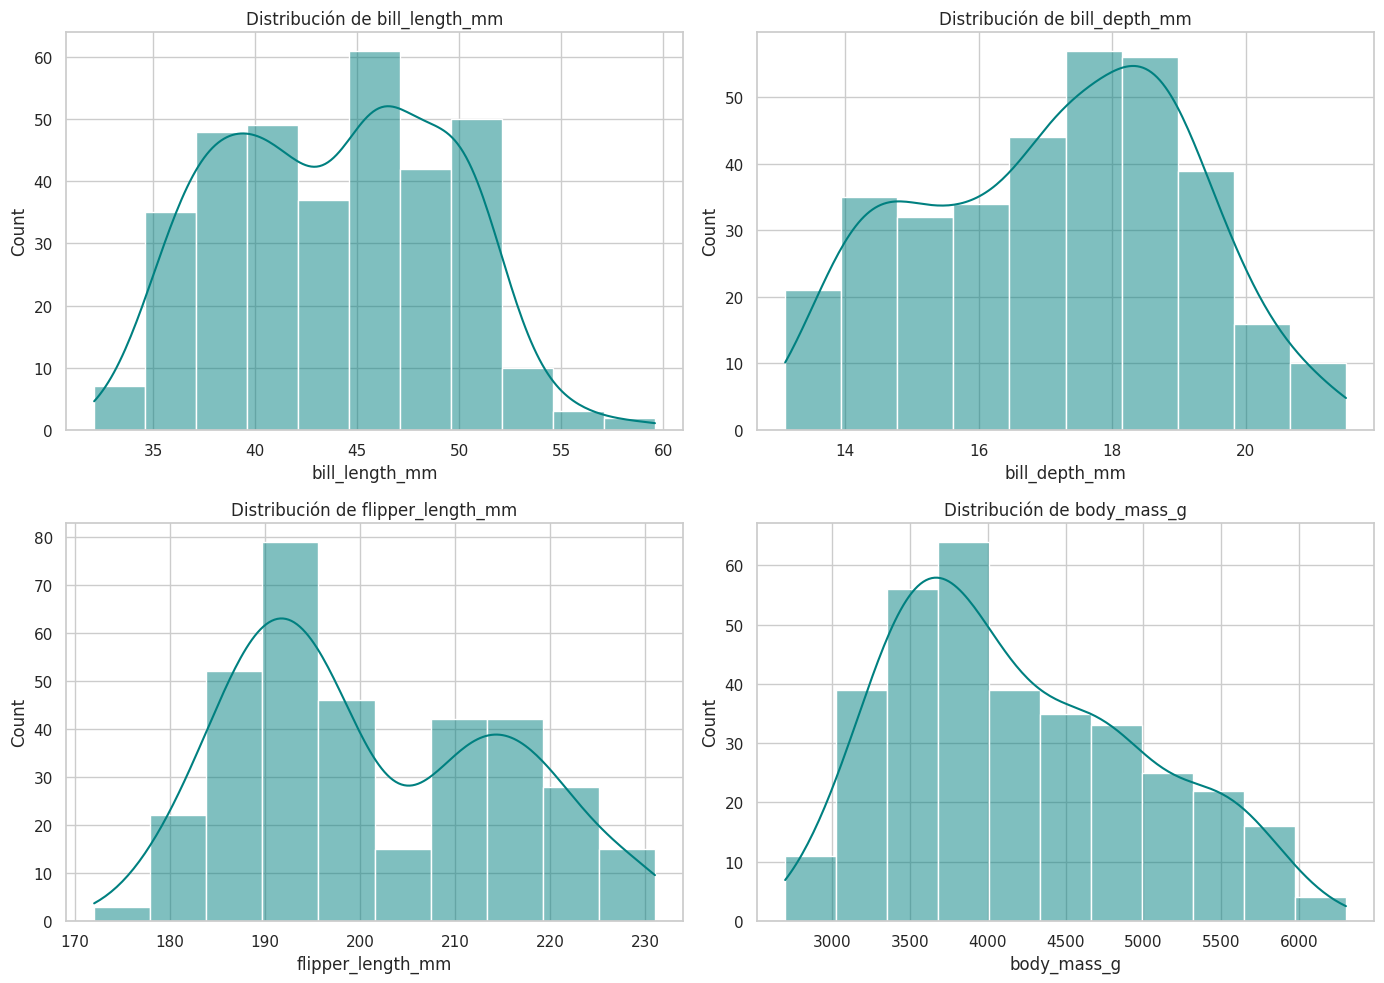

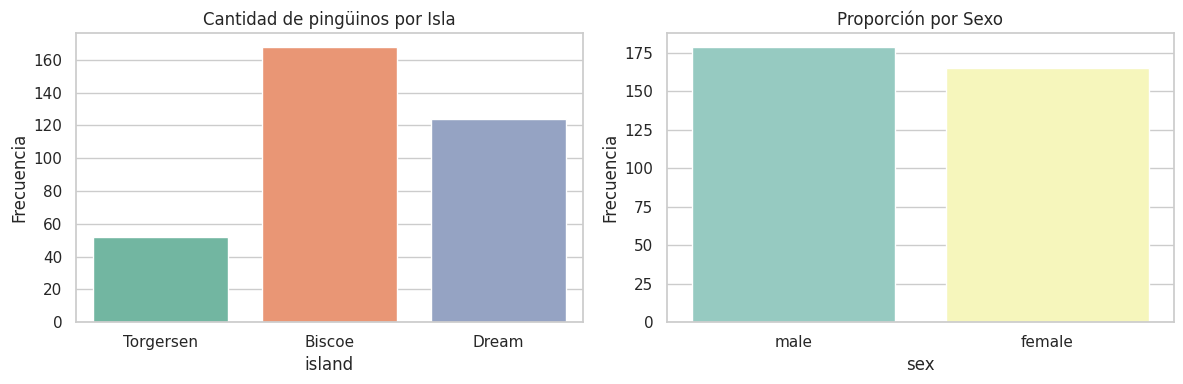

In [6]:
# Análisis de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='species', hue='species', palette='viridis', legend=False)
plt.title('Distribución de Especies de Pingüinos')
plt.ylabel('Cantidad')
plt.xlabel('Especie')
plt.show()

print('\n')

# Distribución de variables numéricas
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(num_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i//2, i%2], color='teal')
    axes[i//2, i%2].set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()
print('\n')

# Análisis Univariado: Distribución de variables categóricas secundarias
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_clean, x='island', hue='island', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Cantidad de pingüinos por Isla')
axes[0].set_ylabel('Frecuencia')

sns.countplot(data=df_clean, x='sex', hue='sex', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Proporción por Sexo')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

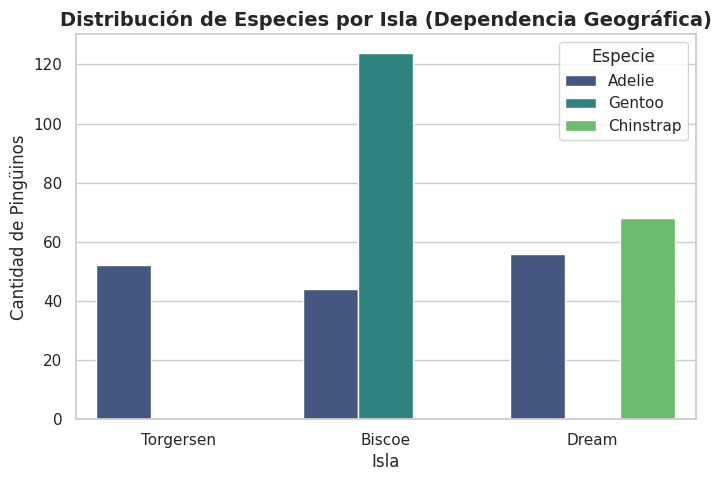

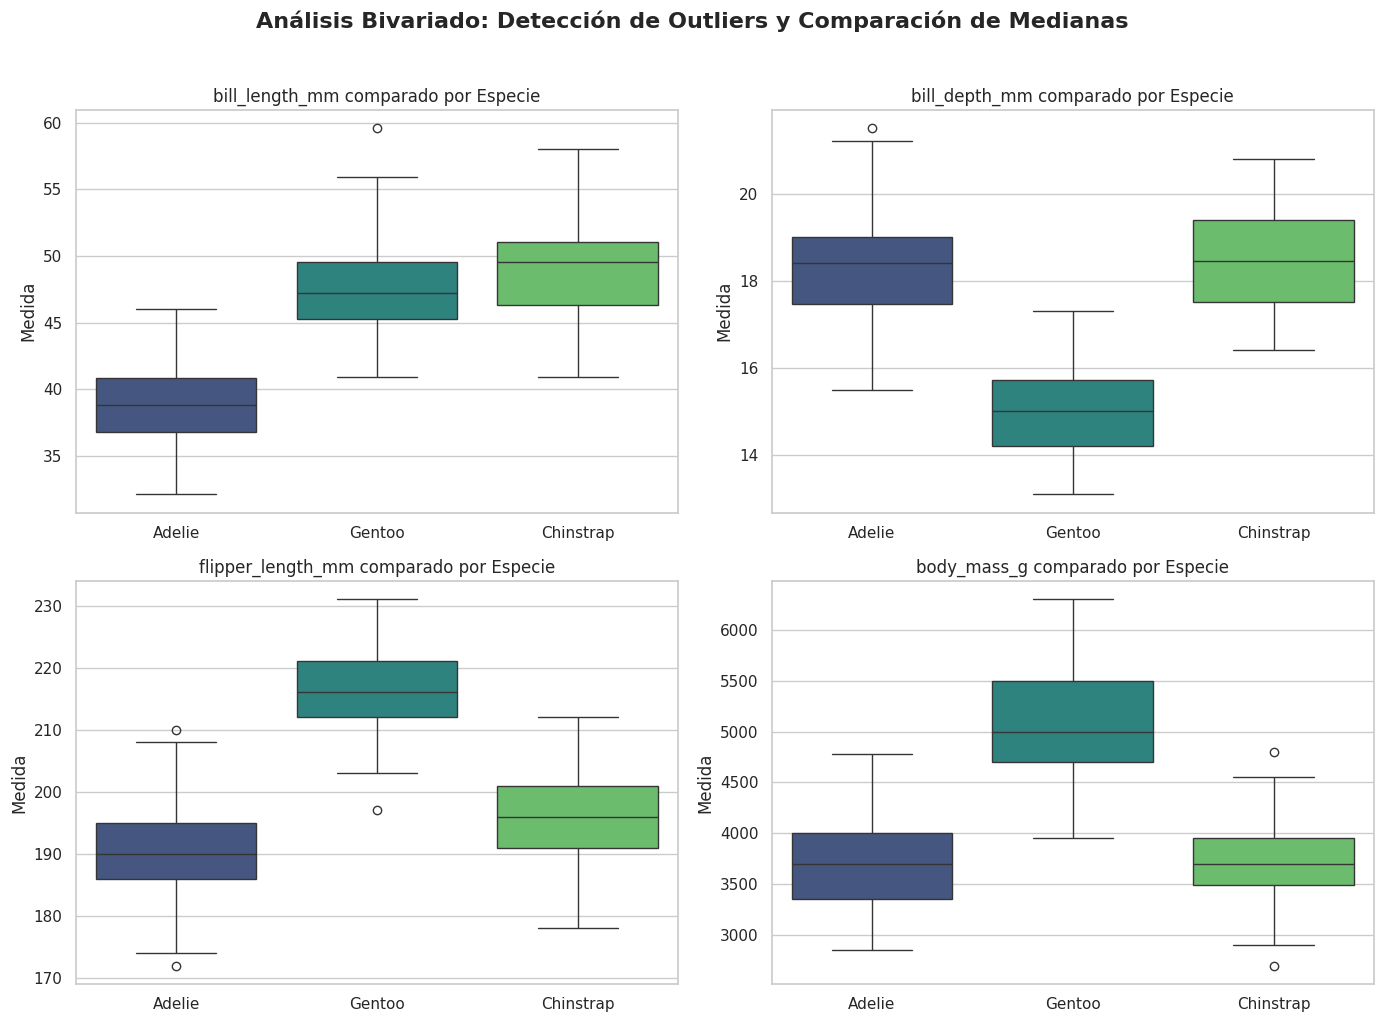

In [30]:
# 1. Bivariado Categórico vs Categórico: Especie por Isla
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x='island',
    hue='species',
    palette='viridis'
)
plt.title('Distribución de Especies por Isla (Dependencia Geográfica)', fontsize=14, fontweight='bold')
plt.xlabel('Isla', fontsize=12)
plt.ylabel('Cantidad de Pingüinos', fontsize=12)
plt.legend(title='Especie', loc='upper right')
plt.show()
print('\n')

# 2. Bivariado Numérico vs Categórico: Boxplots (Diagramas de Caja)
# Definimos las columnas físicas
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Creamos una cuadrícula de 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df_clean,
        x='species',
        y=col,
        hue='species',
        palette='viridis',
        legend=False,
        ax=axes[i//2, i%2]
    )

    axes[i//2, i%2].set_title(f'{col} comparado por Especie', fontsize=12)
    axes[i//2, i%2].set_xlabel('') # Quito la etiqueta 'species' para que no sea redundante
    axes[i//2, i%2].set_ylabel('Medida')

plt.suptitle('Análisis Bivariado: Detección de Outliers y Comparación de Medianas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

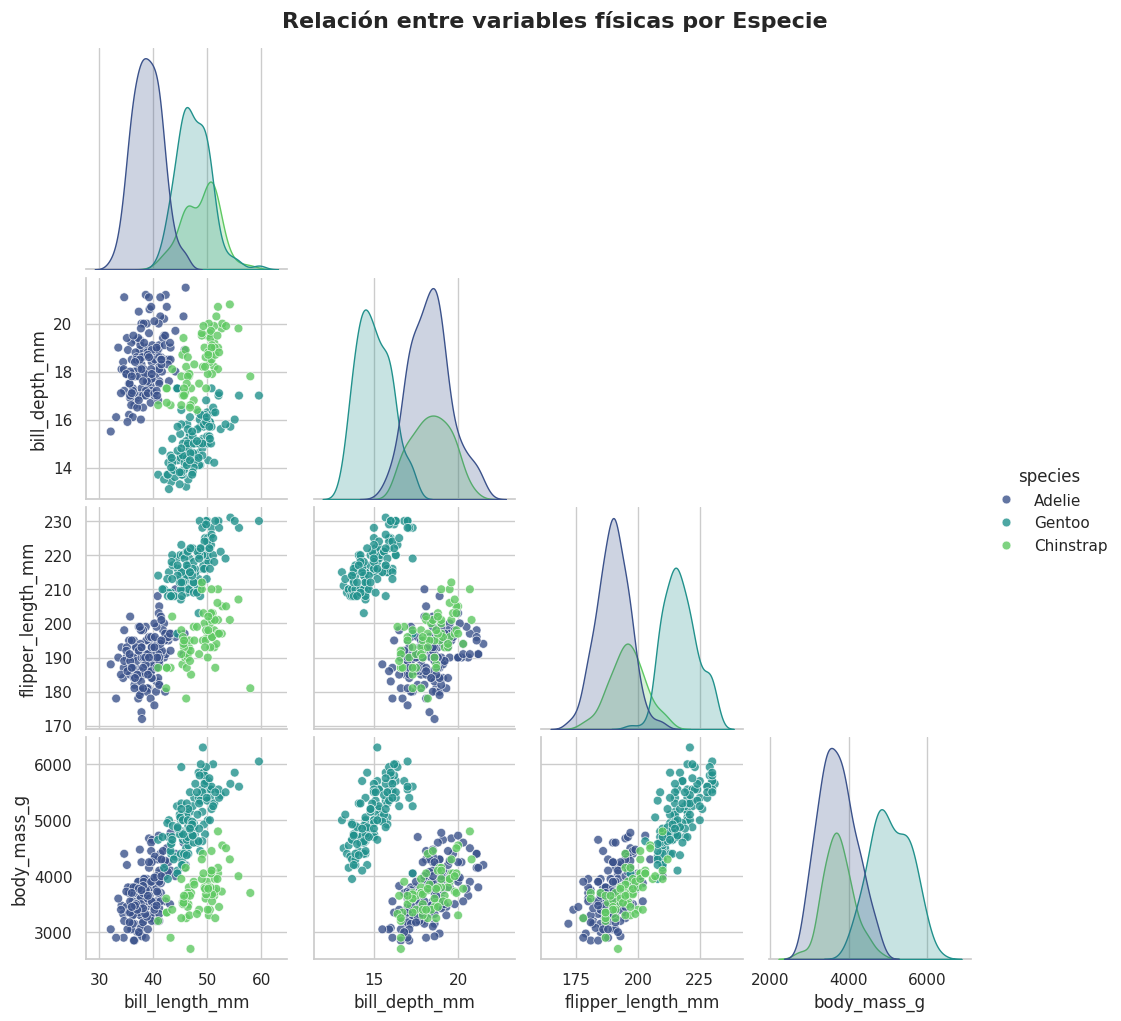

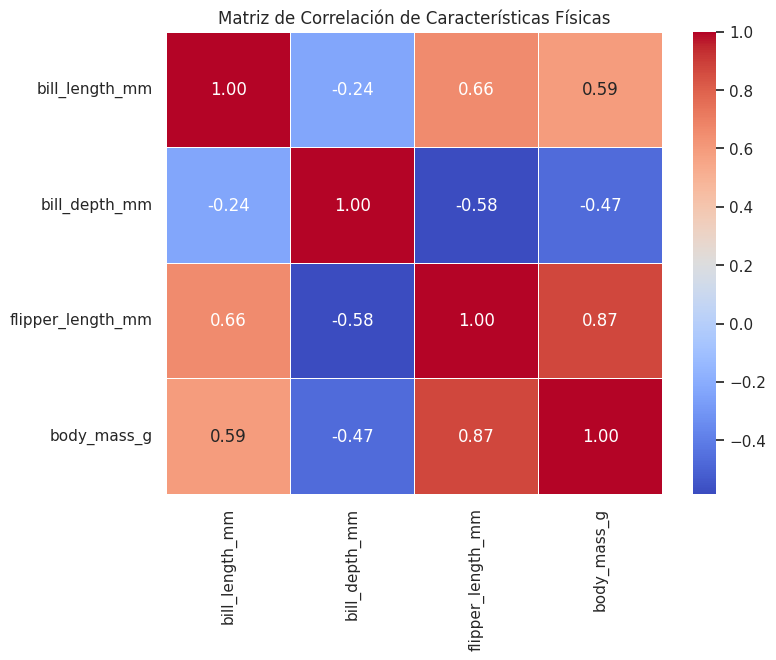

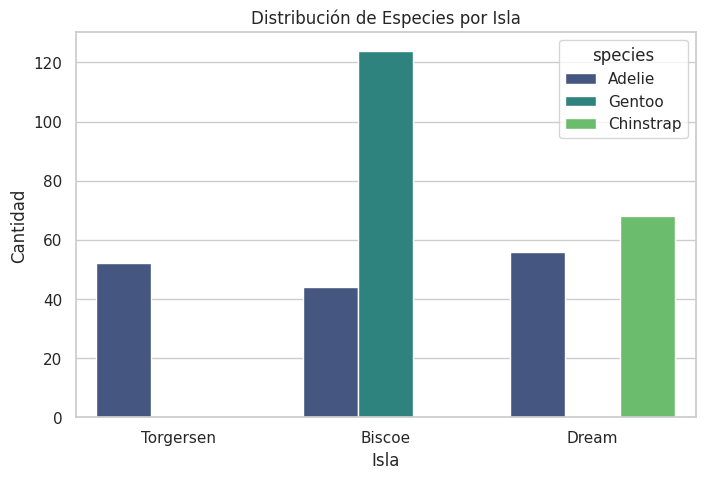

In [7]:
# Pairplot para visualizar la relación entre variables numéricas segmentadas por especie
columnas_fisicas = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','species']

# Generar el pairplot solo con las columnas seleccionadas
sns.pairplot(
    df_clean[columnas_fisicas],
    hue='species',
    palette='viridis',
    corner=True,  # corner=True evita mostrar los gráficos espejo arriba de la diagonal
    plot_kws={'alpha': 0.8, 's': 40, 'edgecolor': 'white'}
)

plt.suptitle('Relación entre variables físicas por Especie', y=1.02, fontsize=16, fontweight='bold')
plt.show()
print('\n')

# Matriz de Correlación
plt.figure(figsize=(8, 6))
correlacion = df_clean[num_cols].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Características Físicas')
plt.show()
print('\n')

# Análisis Bivariado: Distribución de variables segmentadas por especie

# Relación entre Isla y Especie
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='island', hue='species', palette='viridis')
plt.title('Distribución de Especies por Isla')
plt.xlabel('Isla')
plt.ylabel('Cantidad')
plt.show()

## Entrenamiento del Modelo

In [8]:
# Codificación de la variable objetivo (Target)
le_species = LabelEncoder()
df_clean['species_encoded'] = le_species.fit_transform(df_clean['species'])

# Definir características (X) basadas en física
columnas_fisicas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df_clean[columnas_fisicas]
y = df_clean['species_encoded']

print("Características utilizadas para el modelo:")
print(X.columns.tolist())

Características utilizadas para el modelo:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


In [10]:
# División en Train y Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalamiento estandarizado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Set de entrenamiento listo con {X_train.shape[1]} variables físicas.")

Set de entrenamiento listo con 4 variables físicas.


Exactitud Realista (Accuracy): 98.55%

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        30
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.98      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69



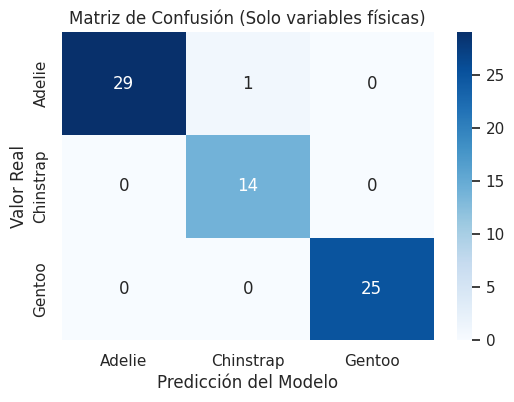

In [11]:
# Entrenamiento del modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = rf_model.predict(X_test_scaled)

# 1. Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud Realista (Accuracy): {accuracy * 100:.2f}%\n")

# 2. Reporte de Clasificación
print("--- Reporte de Clasificación ---")
nombres_clases = le_species.classes_
print(classification_report(y_test, y_pred, target_names=nombres_clases))

# 3. Matriz de Confusión Visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (Solo variables físicas)')
plt.show()

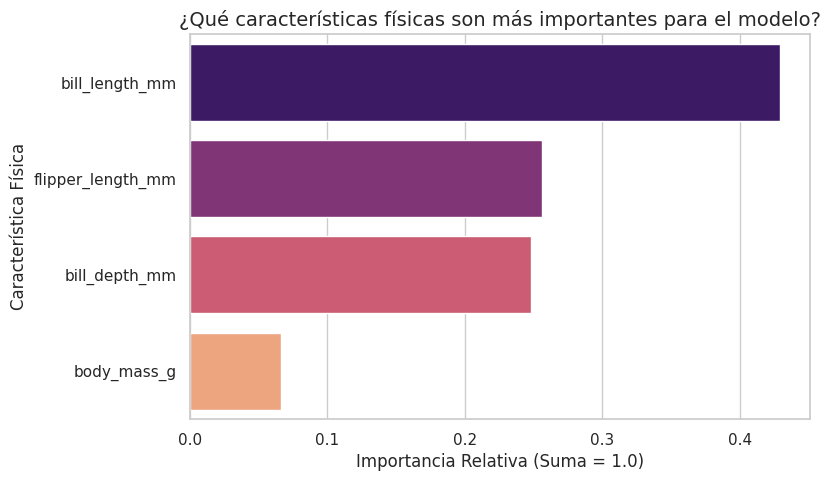



Valores exactos de importancia:


,Característica,Importancia
0,bill_length_mm,0.429510
2,flipper_length_mm,0.255889
1,bill_depth_mm,0.248080
3,body_mass_g,0.066520


In [16]:
# Obtener la importancia de cada variable desde el modelo entrenado
importancias = rf_model.feature_importances_

df_importancias = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': importancias
})

# Ordenar de mayor a menor importancia
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_importancias, x='Importancia', y='Característica', hue='Característica', palette='magma', legend=False)
plt.title('¿Qué características físicas son más importantes para el modelo?', fontsize=14)
plt.xlabel('Importancia Relativa (Suma = 1.0)')
plt.ylabel('Característica Física')
plt.show()
print('\n')

print("Valores exactos de importancia:")
display(df_importancias)

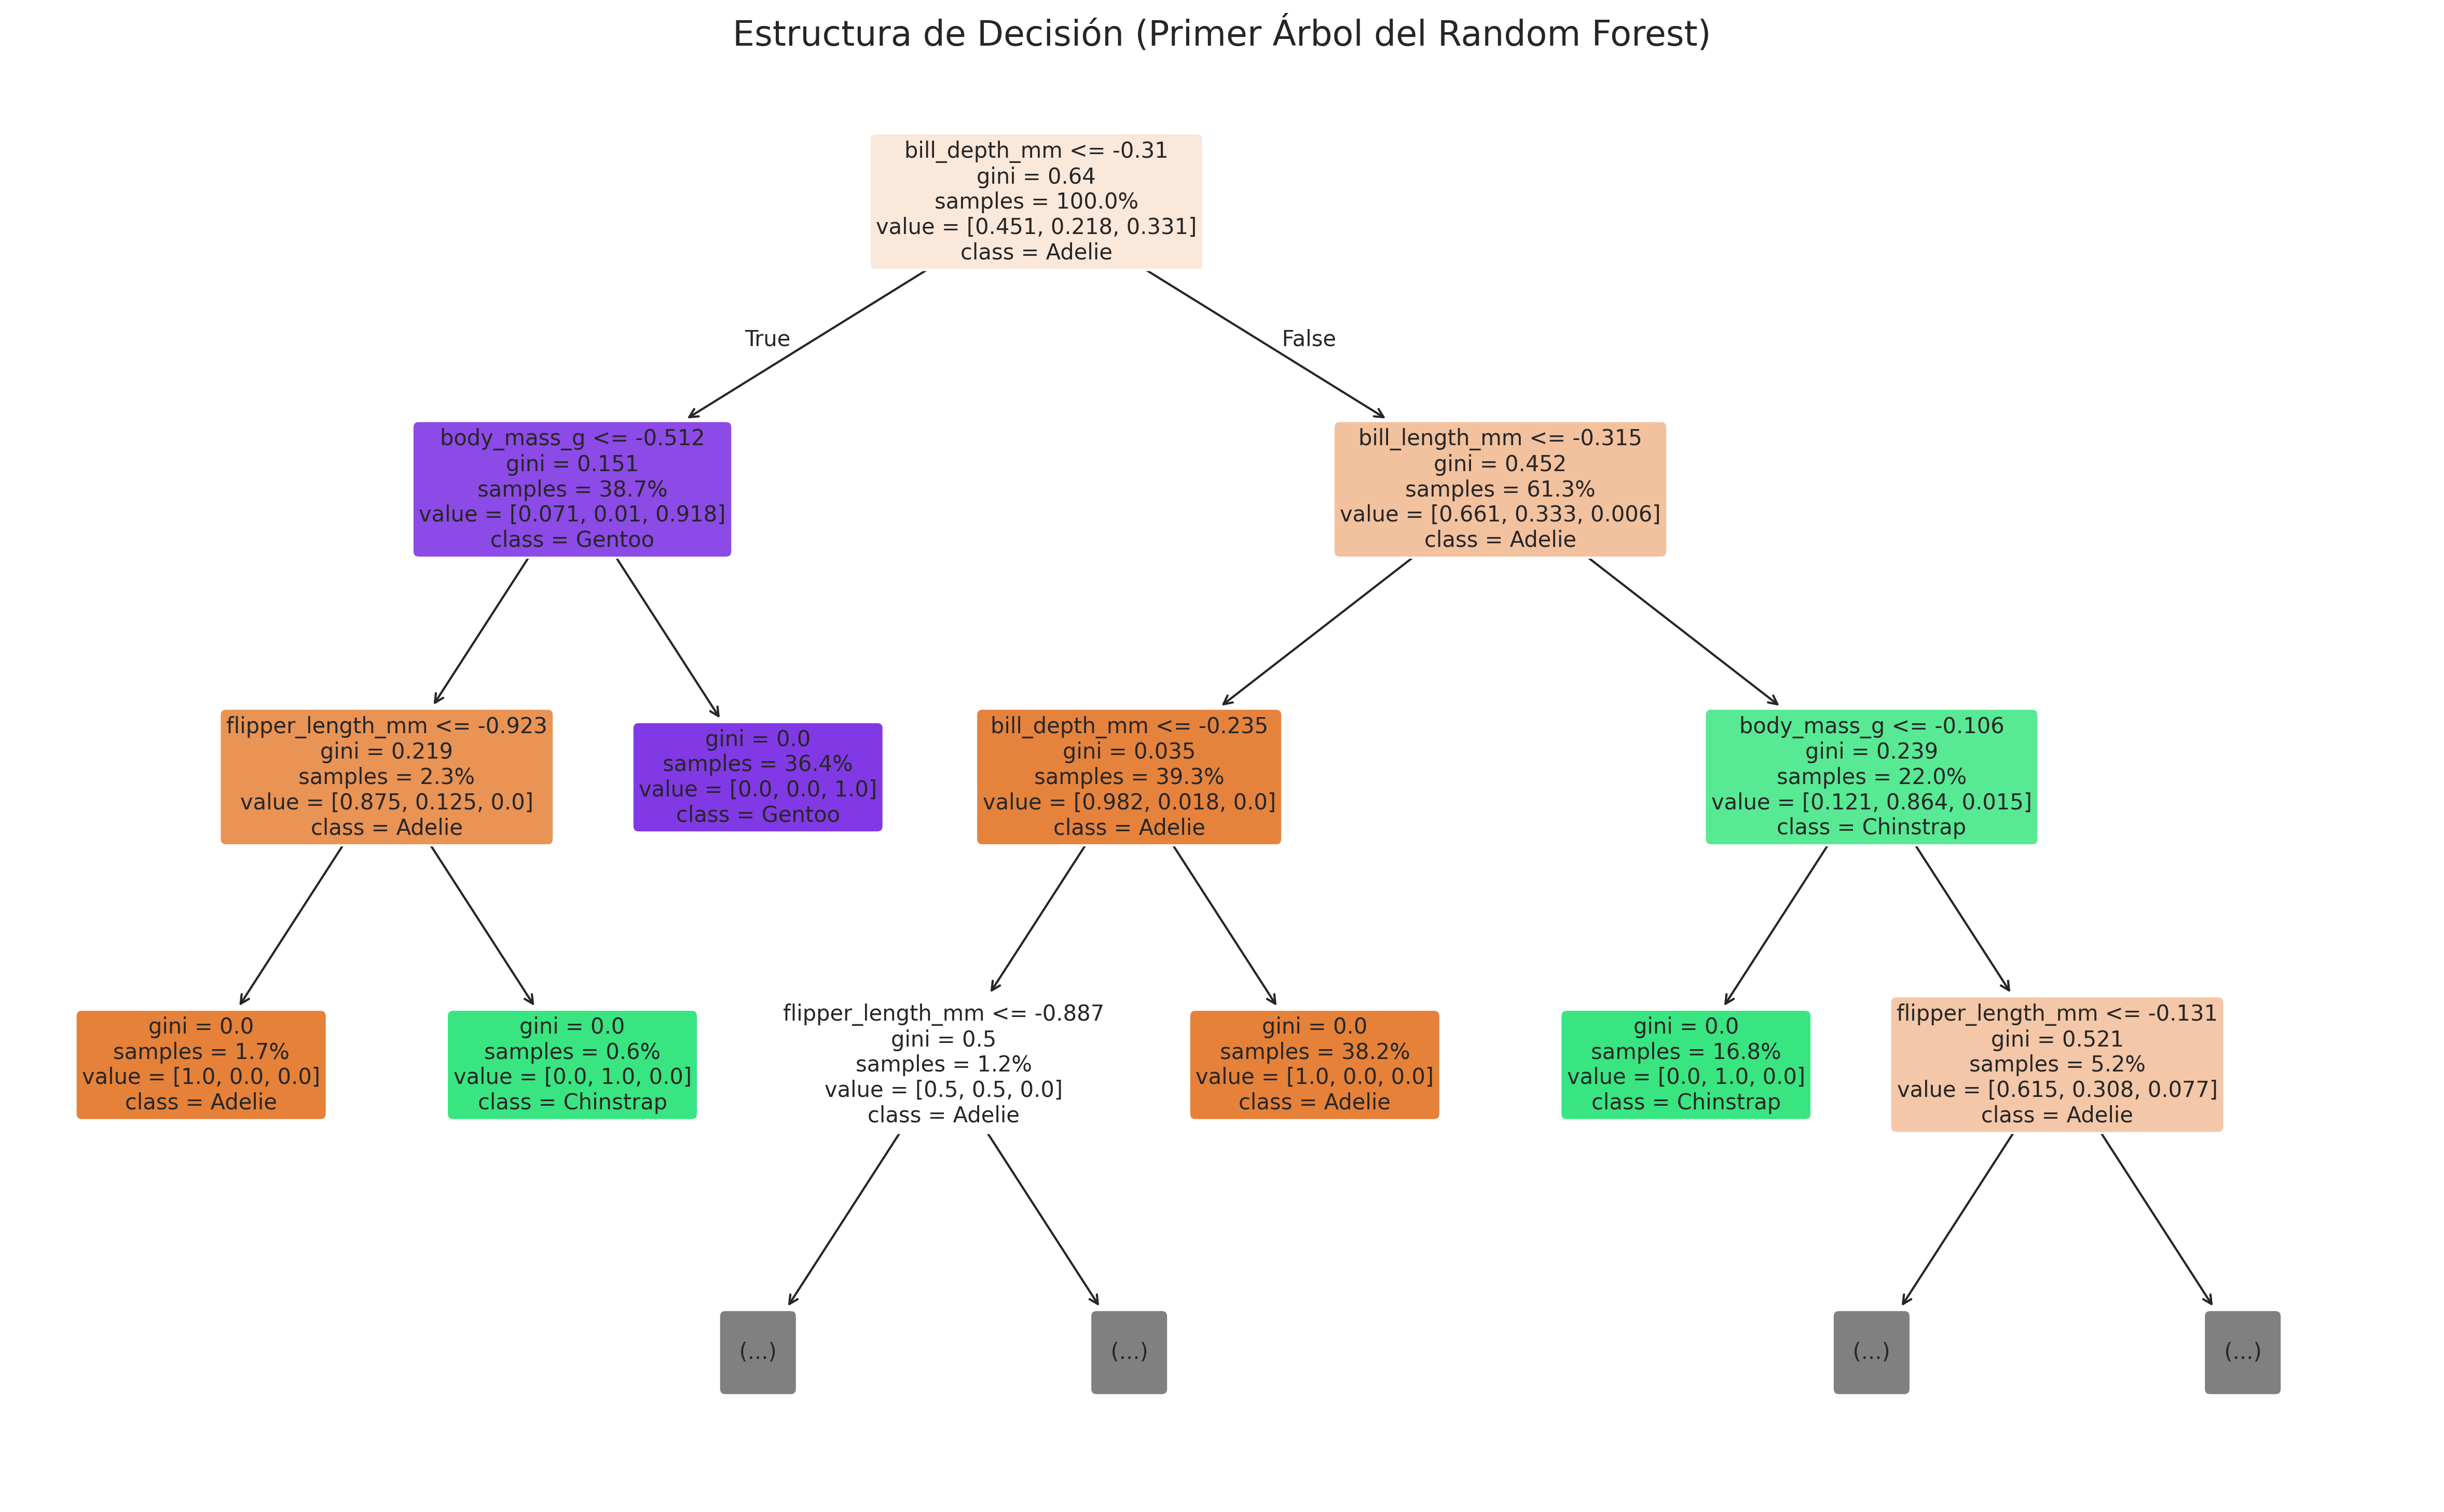

In [31]:
from sklearn.tree import plot_tree

# Extraer un solo árbol del bosque (el primero, en el índice 0)
arbol_individual = rf_model.estimators_[0]

plt.figure(figsize=(20, 12), dpi=300)

plot_tree(
    arbol_individual,
    feature_names=X.columns,
    class_names=list(nombres_clases),
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3,
    proportion=True
)

plt.title('Estructura de Decisión (Primer Árbol del Random Forest)', fontsize=16)
plt.show()